Implementing TunED as in the paper, checking for the driver variable between % of escape and shelter distance in the escape/homing period
Comparison between real and predicted is done using euclidean distance
Stats are done using bootstrap with sampling with replacement

In [ ]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from JR_test_scripts.escape.functions.escape_utils import load, load_homing, compute_dist_shelt, firing_by_bin_median_numba
from JR_test_scripts.escape.functions.escape_data_loading_funcs import extract_homing_and_escape_periods, build_shift_vector
from JR_test_scripts.escape.functions.escape_tuning_funcs import nan_winsorized_mean_2d
from behave_analysis.process.process import Process
from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe, generate_bins
from behave_analysis.analyze.Rayleigh.computeRayleigh import firing_by_angle_bin

import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic, norm
from scipy.ndimage import gaussian_filter1d
from scipy.stats.mstats import winsorize
from matplotlib_venn import venn3

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
"""All the needed functions"""

def tuning_method_TunED(X, y, Nbins, n_neur):
    """
    Computes tuning curves across conditions and neurons, including mean firing rate, 
    variance + (mean^2), and number of samples per bin.

    RETURNS:
        fr_full:    (n_cond, n_neur, bins) - Average firing rate across trials.
    """
    # Nbins = 13
    bin_angles, _ = generate_bins(number_of_bins=Nbins, start=-np.pi, stop=np.pi)
    firing_hist = np.full((n_neur, Nbins-1), np.nan)
    # bin angles
    binned_angles = np.digitize(y, bin_angles) - 1
    for i in range(n_neur):
        firing_hist[i, :] = firing_by_angle_bin(binned_angles, X[:, i], Nbins)

    return firing_hist

def estimate_p_conditional_LF(v1, v2, bin_edges):

    # Compute joint histogram P(v1, v2)
    joint_prob, _, _ = np.histogram2d(v1, v2, bins=[bin_edges, bin_edges], density=True)

    # Compute marginal probability P(v2)
    Pv1 = np.sum(joint_prob, axis=0)
    Pv2 = np.sum(joint_prob, axis=1)

    # Compute conditional probability P(v1 | v2) (avoid division by zero)
    Pv2_v1 = joint_prob / (np.ones(len(Pv2)).reshape(-1, 1) * (Pv1 + 1e-8))
    Pv1_v2 = joint_prob.T / (np.ones(len(Pv1)).reshape(-1, 1) * (Pv2 + 1e-8))  # P(v1|v2)

    return Pv2_v1, Pv1_v2

def compute_expected_tuning_LF(mu_v1, p_v1_given_v2):
    """INPUTS: mu_v1: mean tuning curve for v1
               p_v1_given_v2: conditional probability of v1 given v2"""
    Nbins_x = p_v1_given_v2.shape[1]
    mu_NH_v2 = np.sum((mu_v1[:, None] @ np.ones((1, Nbins_x))) * p_v1_given_v2, axis=0) # Turn ty_y into a column vector and multiply by Py_x
    return mu_NH_v2

def compare_curves(mu_v1, mu_v2, mu_NH_v1, mu_NH_v2):
    """Compute the difference in euclidean distance between real and expected tuning curves"""
    
    dv1 = np.sqrt(np.sum((mu_v1 - mu_NH_v1)**2))
    dv2 = np.sqrt(np.sum((mu_v2 - mu_NH_v2)**2))

    # Store difference
    dv1_minus_dv2 = dv1 - dv2

    return dv1_minus_dv2

In [ ]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept
exp = JAL4_3rdSept

# Load in the data
session = Process(exp).load_session()
base_path = os.path.join(session.base_path, session.processed_path)

# matrix
frame_by_cluster_matrix = np.load(
    os.path.join(session.base_path, session.processed_path)
    + "\\"
    + "frame_by_synthetichdirhsa_cluster_matrix.npy"
)

# behavior
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))
df = filter_video_dataframe(video_df, condition = [], outofshelter=True, exclude_escape=True, exclude_homings=True, select_homings=False, speed_threshold=0)
hdir = np.array(df["hdir"].to_numpy())
hsa = np.array(df["hsa"].to_numpy())
frames = df['frames'].to_numpy()

In [ ]:
"""Load in and extract all necessary data"""

X = frame_by_cluster_matrix[frames-1,:]
n_neur = X.shape[1]

# 6. compute tuning curve for hdir and hsa
Nbins = 13
hdir_firing_hist = tuning_method_TunED(X, hdir, Nbins, n_neur)
hsa_firing_hist = tuning_method_TunED(X, hsa, Nbins, n_neur)

# perform tuned on cells of interest
dv1_minus_dv2 = np.full(n_neur, np.nan, dtype = float)
mu_NH_v2 = np.full((n_neur, Nbins-1), np.nan)
mu_NH_v1 = np.full((n_neur, Nbins-1), np.nan)

v1 = hdir
v2 = hsa
bin_edges = np.arange(Nbins)

for idx in range(n_neur):
    # Step 1: Real Observed Tuning Curves and their variance
    mu_v1 = hdir_firing_hist[idx,:]
    mu_v2 = hsa_firing_hist[idx,:]

    # Step 3: Estimate P(v1 | v2) and P(v2 | v1)
    Pv2_v1, Pv1_v2 = estimate_p_conditional_LF(v1, v2, bin_edges)

    # Step 4: Compute Expected Tuning Curve Under NH
    mu_NH_v2[idx,:] = compute_expected_tuning_LF(mu_v1, Pv1_v2) # tuning to v2 given that driver is v1
    mu_NH_v1[idx,:] = compute_expected_tuning_LF(mu_v2, Pv2_v1) # tuning to v1 given that driver is v2

    # Step 5: Compare Actual vs Expected Tuning for significance
    dv1_minus_dv2[idx] = compare_curves(mu_v1, mu_v2, mu_NH_v1[idx,:], mu_NH_v2[idx,:])

In [40]:
"""This is where we do the tuned boostrapping!"""

# create resampling vectors with replacement, but wuch that we only resample within the same condition
num_samples = 100
frames_vec = np.arange(len(hdir))
resampled_vectors = np.random.choice(frames_vec, (num_samples, len(frames_vec)), replace=True)

dv1_minus_dv2_dist = np.full((num_samples,n_neur), np.nan)
bs_hdir = np.full((resampled_vectors.shape[0],n_neur,Nbins-1),np.nan)
bs_hsa = np.full((resampled_vectors.shape[0],n_neur,Nbins-1),np.nan)
mu_NH_v2_bs = np.full((resampled_vectors.shape[0],n_neur, Nbins-1), np.nan)
mu_NH_v1_bs = np.full((resampled_vectors.shape[0],n_neur, Nbins-1), np.nan)

# iterate over resampling vectors
for i, v in enumerate(resampled_vectors):

    # resample behavioral variables and neural activity
    mat = X[v,:]
    head = hdir[v]
    shelt = hsa[v]

    # step1. recompute tuning curve for distance to shelter with the same number of bins as escape
    bs_hdir[i,:,:] = tuning_method_TunED(mat, head, Nbins, n_neur)
    bs_hsa[i,:,:] = tuning_method_TunED(mat, shelt, Nbins, n_neur)

    for idx in range(n_neur):
        # Step 2: Real Observed Tuning Curves
        mu_v1 = bs_hdir[i, idx,:]
        mu_v2 = bs_hsa[i, idx,:]

        # Step 3: Estimate P(v1 | v2) and P(v2 | v1)
        v1 = head
        v2 = shelt
        bin_edges = np.arange(Nbins)

        Pv2_v1, Pv1_v2 = estimate_p_conditional_LF(v1, v2, bin_edges)

        # Step 4: Compute Expected Tuning Curve Under NH

        mu_NH_v2_bs[i,idx,:] = compute_expected_tuning_LF(mu_v1, Pv1_v2) # tuning to v2 given that driver is v1
        mu_NH_v1_bs[i,idx,:] = compute_expected_tuning_LF(mu_v2, Pv2_v1) # tuning to v1 given that driver is v2

        # Step 5: Compare Actual vs Expected Tuning for significance
        dv1_minus_dv2_dist[i,idx] = compare_curves(mu_v1, mu_v2, mu_NH_v1_bs[i,idx,:], mu_NH_v2_bs[i,idx,:])

Text(0.5, 0, '% escape')

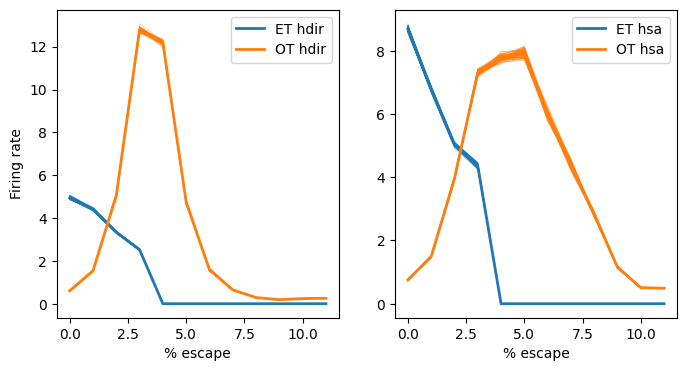

In [41]:
idx = 12

fig, axs = plt.subplots(1,2,figsize = (8,4))
axs[0].plot(mu_NH_v1_bs[:,idx,:].T,'C0',linewidth = .5, alpha = .5)
axs[0].plot(mu_NH_v1[idx,:],'C0',linewidth = 2, label = r'ET hdir')
axs[0].plot(bs_hdir[:, idx,:].T,'C1',linewidth = .5, alpha = .5) # bootstrapped mu_v1
axs[0].plot(hdir_firing_hist[idx,:],'C1',linewidth = 2, label = r'OT hdir') # mu_v1
axs[0].legend()
axs[0].set_ylabel('Firing rate')
axs[0].set_xlabel(r'% escape')

axs[1].plot(mu_NH_v2_bs[:,idx,:].T,'C0',linewidth = .5, alpha = .5)
axs[1].plot(mu_NH_v2[idx,:],'C0',linewidth = 2, label = 'ET hsa')
axs[1].plot(bs_hsa[:, idx,:].T,'C1',linewidth = .5, alpha = .5)
axs[1].plot(hsa_firing_hist[idx,:],'C1',linewidth = 2, label = 'OT hsa') # mu_v2
axs[1].legend()
axs[1].set_xlabel(r'% escape')

Text(0, 0.5, 'number of significant cells')

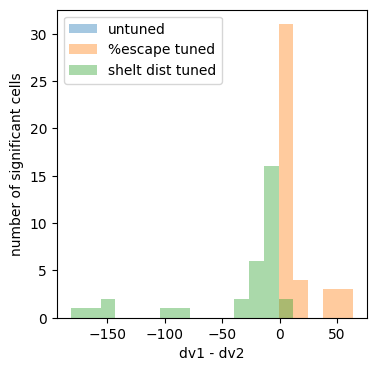

In [44]:

"""Plot the distribution of difference between the distance between v1 and nh_given_v2 and between v2 and nh_given_v1
Show only the cells that are significantly tuned to %escape and shelter distance
Divide cells by whether tuned analysis classifies them as tuned to v1, v2 or undecided"""

c_names = ['shelter_only', 'barrier', 'flipped_barrier']
fig, axs = plt.subplots(1,1,figsize = (4,4))
diff_this_c = dv1_minus_dv2
lower_percentile, upper_percentile = np.percentile(dv1_minus_dv2_dist, [2.5, 97.5], axis = 0)
v1_sig = (lower_percentile > 0) & (upper_percentile > 0)
v2_sig = (lower_percentile < 0) & (upper_percentile < 0)
untuned = ~v1_sig & ~v2_sig
axs.hist(diff_this_c[untuned], bins = np.arange(np.amin(diff_this_c), np.amax(diff_this_c), (np.amax(diff_this_c)-np.amin(diff_this_c))/20), label = r'untuned', alpha = .4)
axs.hist(diff_this_c[v1_sig], bins = np.arange(np.amin(diff_this_c), np.amax(diff_this_c), (np.amax(diff_this_c)-np.amin(diff_this_c))/20), label = r'%escape tuned', alpha = .4)
axs.hist(diff_this_c[v2_sig], bins = np.arange(np.amin(diff_this_c), np.amax(diff_this_c), (np.amax(diff_this_c)-np.amin(diff_this_c))/20), label = r'shelt dist tuned', alpha = .4)
axs.legend()
axs.set_xlabel('dv1 - dv2')
axs.set_ylabel('number of significant cells')

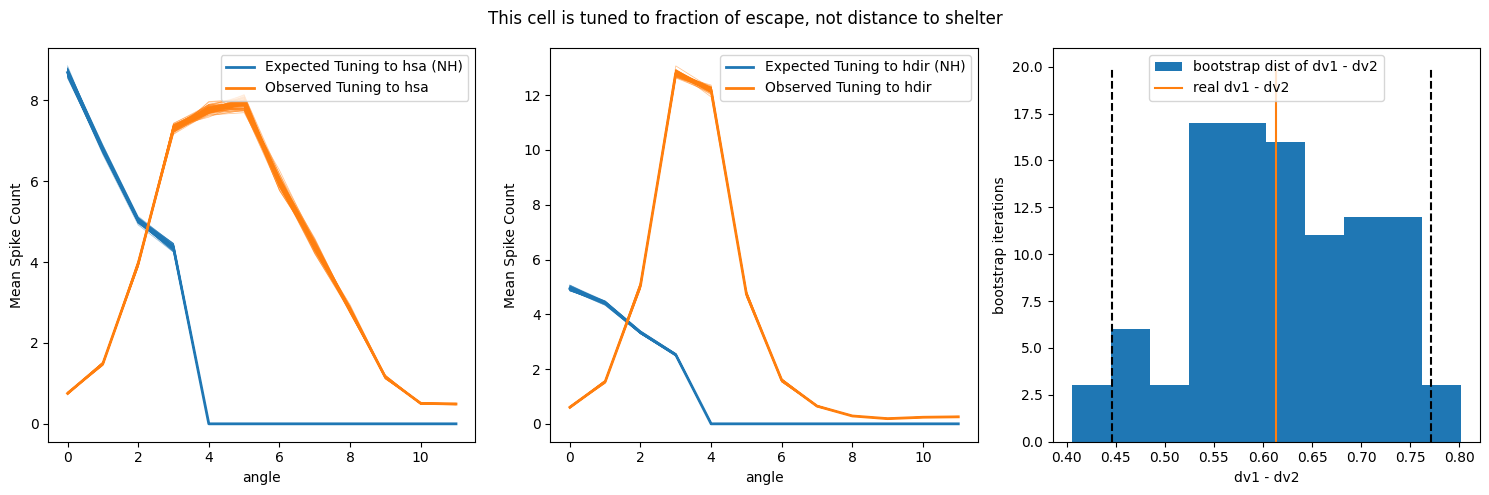

In [50]:
"""Plot LF method for tunED
If a cell is tuned to v1 (escape) then 
    - shifting v1 will cause a significant change in the number of different bins between the v1 observed tuning curve and the expected tuning curve based on v2
    - shifting v2 will not cause a significant change in the number of different bins between the v2 observed tuning curve and the expected tuning curve based on v1
Therefore if we shift v1, is_v1_sig will tell us whether to reject the v2 null hypothesis"""

# choose a cell to test
idx = 12

# Step 1: Real Observed Tuning Curves and their variance
mu_v1 = hdir_firing_hist[idx,:]
mu_v2 = hsa_firing_hist[idx,:]

fig, axs = plt.subplots(1,3,figsize=(15,5))

# Plot Results v1
axs[0].plot(mu_NH_v2_bs[:,idx,:].T,'C0',linewidth = .5, alpha = .5)
axs[0].plot(mu_NH_v2[idx,:],'C0',linewidth = 2, label="Expected Tuning to hsa (NH)")
axs[0].plot(bs_hsa[:, idx,:].T,'C1',linewidth = .5, alpha = .5)
axs[0].plot(hsa_firing_hist[idx,:],'C1',linewidth = 2, label="Observed Tuning to hsa") # mu_v2
axs[0].set_xlabel("angle")
axs[0].set_ylabel("Mean Spike Count")
axs[0].legend()

# Plot Results v2
axs[1].plot(mu_NH_v1_bs[:,idx,:].T,'C0',linewidth = .5, alpha = .5)
axs[1].plot(mu_NH_v1[idx,:],'C0',linewidth = 2, label="Expected Tuning to hdir (NH)")
axs[1].plot(bs_hdir[:, idx,:].T,'C1',linewidth = .5, alpha = .5) # bootstrapped mu_v1
axs[1].plot(hdir_firing_hist[idx,:],'C1',linewidth = 2, label="Observed Tuning to hdir") # mu_v1
axs[1].set_xlabel("angle")
axs[1].set_ylabel("Mean Spike Count")
axs[1].legend()

reject_v1_nh, reject_v2_nh = False, False
lower_percentile, upper_percentile = np.percentile(dv1_minus_dv2_dist[:,idx], [2.5, 97.5])
if lower_percentile < 0 and upper_percentile < 0:
    reject_v1_nh = True # this mean that you can reject the null hypothesis that v1 is the driver, so the cell is tuned to v2
if lower_percentile > 0 and upper_percentile > 0:    
    reject_v2_nh = True # this mean that you can reject the null hypothesis that v2 is the driver, so the cell is tuned to v1

if reject_v2_nh:
    fig.suptitle("This cell is tuned to fraction of escape, not distance to shelter")
if reject_v1_nh:
    fig.suptitle("This cell is tuned to distance to shelter, not fraction of escape")
if not reject_v1_nh and not reject_v2_nh:
    fig.suptitle("This cell is tuned to both fraction of escape and distance to shelter")

axs[2].hist(dv1_minus_dv2_dist[:,idx], label = 'bootstrap dist of dv1 - dv2')
axs[2].plot([dv1_minus_dv2[idx],dv1_minus_dv2[idx]],[0,20], label = 'real dv1 - dv2')
axs[2].plot([lower_percentile,lower_percentile],[0,20],'--k')
axs[2].plot([upper_percentile,upper_percentile],[0,20],'--k')
axs[2].set_xlabel('dv1 - dv2')
axs[2].set_ylabel('bootstrap iterations')
axs[2].legend()

plt.tight_layout()
plt.show()